In [92]:
import pandas as pd
file = "/Users/majjaripranay/Documents/ML_CODES/Clarity_Text_student_teacher_with_glove.xlsx"

data = pd.read_excel(file)
X=data.iloc[3:]
y=data["Label"]

In [93]:
import numpy as np
import matplotlib.pyplot as plt

# Summation Unit
def summation(x, w):
    return np.dot(x, w)

# Activation Functions
def step(x):
    return 1 if x >= 0 else 0

def bipolar_step(x):
    return 1 if x >= 0 else -1

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return max(0, x)

def leaky_relu(x):
    return x if x > 0 else 0.01 * x

# Comparator
def error(target, output):
    return target - output

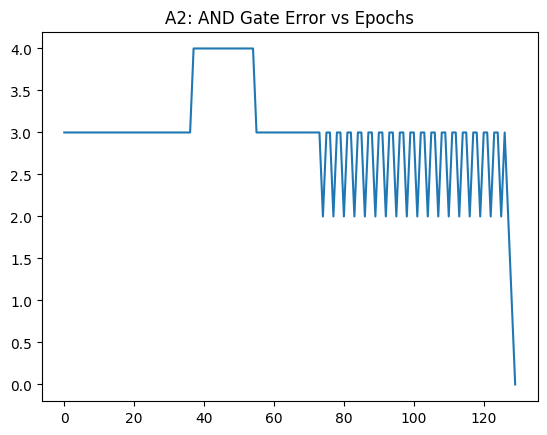

In [94]:
def train_perceptron(X, y, w, lr, activation):
    errors = []
    for epoch in range(1000):
        total_error = 0
        for i in range(len(X)):
            net = summation(X[i], w)
            out = activation(net)
            e = error(y[i], out)
            total_error += e**2
            w = w + lr * e * X[i]
        errors.append(total_error)
        if total_error <= 0.002:
            break
    return w, errors, epoch

# AND Gate
X_and = np.array([[1,0,0],[1,0,1],[1,1,0],[1,1,1]])
y_and = np.array([0,0,0,1])

w = np.array([10,0.2,-0.75])
lr = 0.05

w_final, err, epochs = train_perceptron(X_and, y_and, w, lr, step)

plt.plot(err)
plt.title("A2: AND Gate Error vs Epochs")
plt.show()

In [95]:
##A3
activations = {
    "Bipolar": bipolar_step,
    "Sigmoid": sigmoid,
    "ReLU": relu
}

results = {}

for name, func in activations.items():
    w = np.array([10,0.2,-0.75])
    _, _, epochs = train_perceptron(X_and, y_and, w, lr, func)
    results[name] = epochs

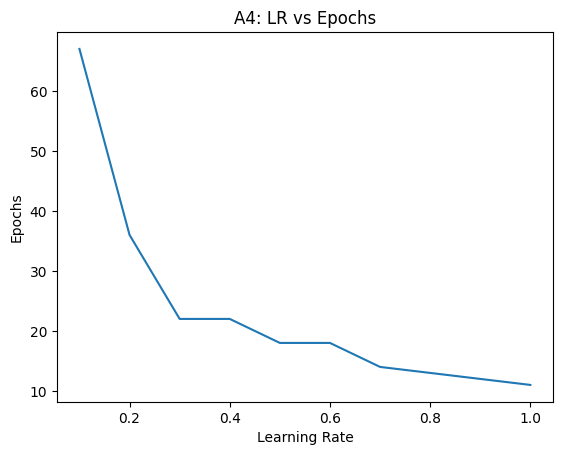

In [96]:
##A4
lrs = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
epoch_list = []

for lr_val in lrs:
    w = np.array([10,0.2,-0.75])
    _, _, epochs = train_perceptron(X_and, y_and, w, lr_val, step)
    epoch_list.append(epochs)

plt.plot(lrs, epoch_list)
plt.xlabel("Learning Rate")
plt.ylabel("Epochs")
plt.title("A4: LR vs Epochs")
plt.show()

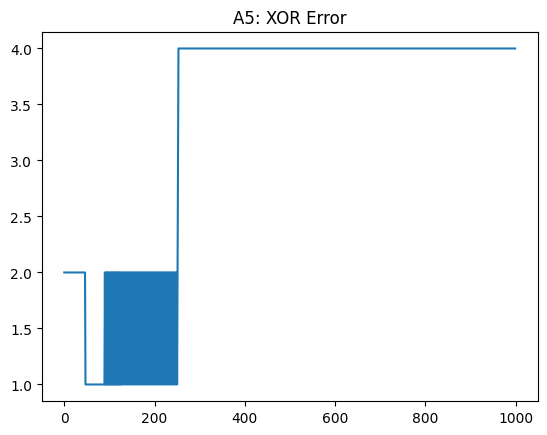

In [97]:
##A5
X_xor = np.array([[1,0,0],[1,0,1],[1,1,0],[1,1,1]])
y_xor = np.array([0,1,1,0])

w = np.array([10,0.2,-0.75])
w_final, err, epochs = train_perceptron(X_xor, y_xor, w, lr, step)

plt.plot(err)
plt.title("A5: XOR Error")
plt.show()

/var/folders/r6/zpb4fs893qg60v635p54k2f80000gn/T/ipykernel_11237/3334215509.py:16: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


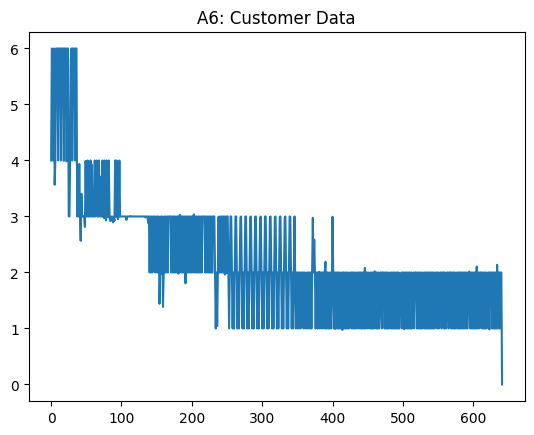

In [98]:
##A6
X_cust = np.array([
[1,20,6,2,386],
[1,16,3,6,289],
[1,27,6,2,393],
[1,19,1,2,110],
[1,24,4,2,280],
[1,22,1,5,167],
[1,15,4,2,271],
[1,18,4,2,274],
[1,21,1,4,148],
[1,16,2,4,198]
])

y_cust = np.array([1,1,1,0,1,0,1,1,0,0])

w = np.random.rand(5)
lr = 0.01

w_final, err, epochs = train_perceptron(X_cust, y_cust, w, lr, sigmoid)

plt.plot(err)
plt.title("A6: Customer Data")
plt.show()

In [99]:
##A7
def pseudo_inverse(X, y):
    return np.linalg.pinv(X).dot(y)

w_pinv = pseudo_inverse(X_cust, y_cust)

In [100]:
##A8
def sigmoid_deriv(x):
    return x * (1 - x)

def train_nn(X, y, lr):
    w = np.random.rand(3,1)
    for epoch in range(1000):
        total_error = 0
        for i in range(len(X)):
            x = X[i].reshape(1,-1)
            target = y[i]

            out = sigmoid(np.dot(x, w))
            e = target - out
            total_error += e**2

            w += lr * e * sigmoid_deriv(out) * x.T

        if total_error <= 0.002:
            break
    return w, epoch
    

In [101]:
##A10
y_and_2 = np.array([
[1,0],
[1,0],
[1,0],
[0,1]
])

def train_multi_output(X, Y, w, lr):
    for epoch in range(1000):
        total_error = 0
        for i in range(len(X)):
            out = sigmoid(np.dot(X[i], w))
            e = Y[i] - out
            total_error += np.sum(e**2)
            w += lr * np.outer(X[i], e)
        if total_error <= 0.002:
            break
    return w

In [102]:
##A11
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(2,), max_iter=1000)

mlp.fit(X_and[:,1:], y_and)   # remove bias column
pred_and = mlp.predict(X_and[:,1:])

mlp.fit(X_xor[:,1:], y_xor)
pred_xor = mlp.predict(X_xor[:,1:])

In [103]:
mlp = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000)

mlp.fit(X_cust[:,1:], y_cust)
pred_cust = mlp.predict(X_cust[:,1:])